# Apendice Tema 2 - Cinematica del Solido Rigido

**Teoria de Maquinas y Mecanismos - 2o GIERM**

---

## Objetivos de aprendizaje

- Comprender la **condicion cinematica de rigidez** y su formulacion en velocidades y aceleraciones
- Demostrar y aplicar el **Teorema de Chasles** ($\vec{v}_{21}^P = \vec{v}_{21}^O + \vec{\omega}_{21} \wedge \overrightarrow{OP}$)
- Derivar las **formulas de Poisson** para la derivada de vectores unitarios en ejes moviles
- Calcular la **derivada de un vector** expresado en un sistema de referencia movil
- Aplicar la **composicion de movimientos relativos** en velocidades y aceleraciones
- Identificar y calcular la **aceleracion de Coriolis** ($2\vec{\omega}_{21} \wedge \vec{v}_{32}^P$)
- Resolver ejercicios de cinematica del solido rigido plano

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Arc, Circle, Rectangle, Polygon
from matplotlib.lines import Line2D

# --- Paleta de colores estandar ---
COLOR_PRINCIPAL = '#2171b5'   # Azul - barras, curvas principales
COLOR_FIJO      = '#636363'   # Gris oscuro - barra fija / suelo
COLOR_PUNTO     = '#238b45'   # Verde - puntos de operacion, resultados
COLOR_ROJO      = '#cb181d'   # Rojo - fuerzas, errores, alertas
COLOR_NARANJA   = '#ff7f00'   # Naranja - secundario
COLOR_MORADO    = '#6a3d9a'   # Morado - terciario
COLOR_CLARO     = '#a6cee3'   # Azul claro - rellenos

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.grid': True,
    'axes.grid.which': 'major',
    'grid.alpha': 0.3,
    'lines.linewidth': 1.5,
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.figsize': (12, 6),
})

# --- Helpers de dibujo para mecanismos ---
def draw_link(ax, p1, p2, color=COLOR_PRINCIPAL, lw=5, zorder=2):
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], '-', color=color, lw=lw,
            solid_capstyle='round', zorder=zorder)

def draw_joint(ax, p, fixed=False, color='black', ms=10, zorder=5):
    if fixed:
        ax.plot(p[0], p[1], 's', color=color, ms=ms, zorder=zorder,
                markeredgecolor='black', markeredgewidth=1.5)
    else:
        ax.plot(p[0], p[1], 'o', color='white', ms=ms, zorder=zorder,
                markeredgecolor='black', markeredgewidth=2)

def draw_ground(ax, center, width, y_offset=-0.15):
    x0 = center[0] - width/2
    y0 = center[1] + y_offset
    n_hash = 8
    for i in range(n_hash + 1):
        xi = x0 + i * width / n_hash
        ax.plot([xi, xi - 0.08], [y0, y0 - 0.12], 'k-', lw=0.8, zorder=1)
    ax.plot([x0, x0 + width], [y0, y0], 'k-', lw=1.5, zorder=1)

def draw_vector(ax, origin, vec, color=COLOR_ROJO, lw=2, label=None, fontsize=13):
    ax.annotate('', xy=(origin[0]+vec[0], origin[1]+vec[1]), xytext=origin,
                arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                mutation_scale=15))
    if label:
        mid = (origin[0]+vec[0]/2, origin[1]+vec[1]/2)
        ax.text(mid[0]+0.05, mid[1]+0.1, label, fontsize=fontsize,
                color=color, fontweight='bold')

Configuracion y helpers de dibujo cargados.


---

## 1. Formulario del Tema

| Concepto | Formula | Notas |
|----------|---------|-------|
| **Condicion de rigidez** | $|\vec{r}_{21}^P - \vec{r}_{21}^O|^2 = \text{cte}$ | Distancia entre dos puntos del solido constante |
| **Campo de velocidades** | $(\vec{r}_{21}^P - \vec{r}_{21}^O) \cdot (\vec{v}_{21}^P - \vec{v}_{21}^O) = 0$ | Campo **equiproyectivo** |
| **Teorema de Chasles** | $\vec{v}_{21}^P = \vec{v}_{21}^O + \vec{\omega}_{21} \wedge \overrightarrow{OP}$ | Traslacion + rotacion |
| **Formulas de Poisson** | $\dfrac{d\vec{i}_2}{dt} = \vec{\omega}_{21} \wedge \vec{i}_2$, idem $\vec{j}_2$, $\vec{k}_2$ | Derivada de vectores unitarios del triedro movil |
| **Derivada en ejes moviles** | $\left.\dfrac{d\vec{A}}{dt}\right|_1 = \left.\dfrac{d\vec{A}}{dt}\right|_2 + \vec{\omega}_{21} \wedge \vec{A}$ | Relacion derivada absoluta/relativa |
| **Aceleracion del SR** | $\vec{a}_{21}^P = \vec{a}_{21}^O + \vec{\alpha}_{21} \wedge \overrightarrow{OP} + \vec{\omega}_{21} \wedge (\vec{\omega}_{21} \wedge \overrightarrow{OP})$ | Tangencial + centripeta |
| **Caso plano** | $\vec{a}_{21}^P = \vec{a}_{21}^O + \vec{\alpha}_{21} \wedge \overrightarrow{OP} - \omega_{21}^2 \overrightarrow{OP}$ | BAC-CAB simplificado |
| **Composicion velocidades** | $\vec{v}_{31}^P = \vec{v}_{32}^P + \vec{v}_{21}^P$ | Mov. relativo |
| **Composicion omega** | $\vec{\omega}_{31} = \vec{\omega}_{32} + \vec{\omega}_{21}$ | (tambien $\omega_{ij} = \omega_{ik} + \omega_{kj}$) |
| **Composicion aceleraciones** | $\vec{a}_{31}^P = \vec{a}_{32}^P + \vec{a}_{21}^P + 2\vec{\omega}_{21} \wedge \vec{v}_{32}^P$ | Incluye **Coriolis** |
| **Composicion alpha** | $\vec{\alpha}_{ij} = \vec{\alpha}_{ik} + \vec{\alpha}_{kj}$ | Se suma directamente |

---

## 2. Condicion cinematica de rigidez

Un **solido rigido** es aquel en el que la distancia entre cualesquiera dos de sus puntos permanece constante a lo largo del tiempo.

Sean $O$ y $P$ dos puntos cualesquiera del solido (cuerpo 2) moviendose respecto al sistema de referencia 1:

$$|\overrightarrow{OP}|^2 = (\vec{r}_{21}^P - \vec{r}_{21}^O) \cdot (\vec{r}_{21}^P - \vec{r}_{21}^O) = \text{constante}$$

Derivando respecto al tiempo:

$$\frac{d}{dt}|\overrightarrow{OP}|^2 = 2(\vec{r}_{21}^P - \vec{r}_{21}^O) \cdot (\vec{v}_{21}^P - \vec{v}_{21}^O) = 0$$

Es decir:

$$\overrightarrow{OP} \cdot (\vec{v}_{21}^P - \vec{v}_{21}^O) = 0$$

Esto significa que la diferencia de velocidades entre dos puntos del solido es **perpendicular** al segmento que los une. Dicho de otra forma, las proyecciones de las velocidades de $O$ y $P$ sobre la recta $OP$ son iguales: el campo de velocidades es **equiproyectivo**.

> **Campo equiproyectivo**: Para todo par de puntos $O$, $P$ del solido rigido, la proyeccion de $\vec{v}_O$ sobre $\overrightarrow{OP}$ es igual a la proyeccion de $\vec{v}_P$ sobre $\overrightarrow{OP}$.

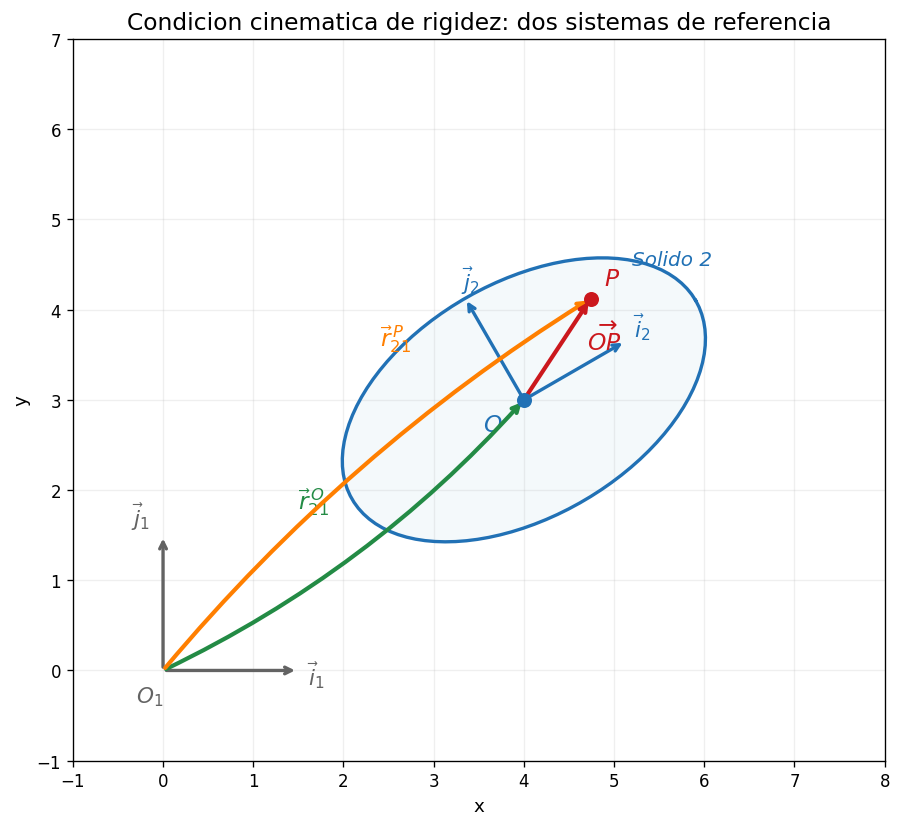

In [2]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
ax.set_xlim(-1, 8)
ax.set_ylim(-1, 7)
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)
ax.set_title('Condicion cinematica de rigidez: dos sistemas de referencia', fontsize=14)

# --- Sistema fijo (1) ---
orig1 = np.array([0.0, 0.0])
ax.annotate('', xy=(1.5, 0), xytext=orig1,
            arrowprops=dict(arrowstyle='->', color=COLOR_FIJO, lw=2))
ax.annotate('', xy=(0, 1.5), xytext=orig1,
            arrowprops=dict(arrowstyle='->', color=COLOR_FIJO, lw=2))
ax.text(1.6, -0.15, r'$\vec{i}_1$', fontsize=13, color=COLOR_FIJO)
ax.text(-0.35, 1.6, r'$\vec{j}_1$', fontsize=13, color=COLOR_FIJO)
ax.text(-0.3, -0.35, r'$O_1$', fontsize=13, color=COLOR_FIJO, fontweight='bold')

# --- Sistema movil (2) centrado en O del solido ---
O2 = np.array([4.0, 3.0])
theta = np.radians(30)
i2 = np.array([np.cos(theta), np.sin(theta)])
j2 = np.array([-np.sin(theta), np.cos(theta)])

ax.annotate('', xy=O2 + 1.3*i2, xytext=O2,
            arrowprops=dict(arrowstyle='->', color=COLOR_PRINCIPAL, lw=2))
ax.annotate('', xy=O2 + 1.3*j2, xytext=O2,
            arrowprops=dict(arrowstyle='->', color=COLOR_PRINCIPAL, lw=2))
ax.text(*(O2 + 1.4*i2), r'$\vec{i}_2$', fontsize=13, color=COLOR_PRINCIPAL)
ax.text(*(O2 + 1.4*j2), r'$\vec{j}_2$', fontsize=13, color=COLOR_PRINCIPAL)
ax.text(O2[0]-0.45, O2[1]-0.35, r'$O$', fontsize=14, color=COLOR_PRINCIPAL, fontweight='bold')

# --- Solido rigido (elipse) ---
t_el = np.linspace(0, 2*np.pi, 100)
a_el, b_el = 2.2, 1.3
x_el = O2[0] + a_el*np.cos(t_el)*np.cos(theta) - b_el*np.sin(t_el)*np.sin(theta)
y_el = O2[1] + a_el*np.cos(t_el)*np.sin(theta) + b_el*np.sin(t_el)*np.cos(theta)
ax.fill(x_el, y_el, alpha=0.12, color=COLOR_CLARO)
ax.plot(x_el, y_el, '-', color=COLOR_PRINCIPAL, lw=2)
ax.text(O2[0]+1.2, O2[1]+1.5, 'Solido 2', fontsize=12, color=COLOR_PRINCIPAL,
        fontstyle='italic')

# --- Punto P dentro del solido ---
P = O2 + 1.2*i2 + 0.6*j2
ax.plot(*P, 'o', color=COLOR_ROJO, ms=8, zorder=5)
ax.text(P[0]+0.15, P[1]+0.15, r'$P$', fontsize=14, color=COLOR_ROJO, fontweight='bold')

# --- Vector de posicion r_21^O ---
ax.annotate('', xy=O2, xytext=orig1,
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=2.5,
                            connectionstyle='arc3,rad=0.1'))
ax.text(1.5, 1.8, r'$\vec{r}_{21}^{\,O}$', fontsize=14, color=COLOR_PUNTO, fontweight='bold')

# --- Vector de posicion r_21^P ---
ax.annotate('', xy=P, xytext=orig1,
            arrowprops=dict(arrowstyle='->', color=COLOR_NARANJA, lw=2.5,
                            connectionstyle='arc3,rad=-0.08'))
ax.text(2.4, 3.6, r'$\vec{r}_{21}^{\,P}$', fontsize=14, color=COLOR_NARANJA, fontweight='bold')

# --- Vector OP ---
ax.annotate('', xy=P, xytext=O2,
            arrowprops=dict(arrowstyle='->', color=COLOR_ROJO, lw=2.5))
ax.text(O2[0]+0.7, O2[1]+0.55, r'$\overrightarrow{OP}$', fontsize=14,
        color=COLOR_ROJO, fontweight='bold')

# --- Punto O del solido ---
ax.plot(*O2, 'o', color=COLOR_PRINCIPAL, ms=8, zorder=5)

ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
plt.show()

---

## 3. Teorema de Chasles

El campo equiproyectivo tiene una estructura matematica concreta. Se puede demostrar que existe un unico vector $\vec{\omega}_{21}$ (la **velocidad angular**) tal que para todo punto $P$ del solido:

$$\boxed{\vec{v}_{21}^P = \vec{v}_{21}^O + \vec{\omega}_{21} \wedge \overrightarrow{OP}}$$

Esto descompone el movimiento de cualquier punto en:

1. **Traslacion** con la velocidad del punto de referencia $O$: $\vec{v}_{21}^O$
2. **Rotacion** alrededor de $O$: $\vec{\omega}_{21} \wedge \overrightarrow{OP}$

### Propiedades importantes

- $\vec{\omega}_{21}$ es **independiente** del punto de referencia $O$ elegido
- En movimiento plano: $\vec{\omega}_{21} = \omega_{21} \vec{k}$ (perpendicular al plano)
- Si $\vec{\omega}_{21} = \vec{0}$: movimiento de **traslacion pura** (todas las velocidades iguales)
- Si $\vec{v}_{21}^O = \vec{0}$: movimiento de **rotacion pura** alrededor de $O$

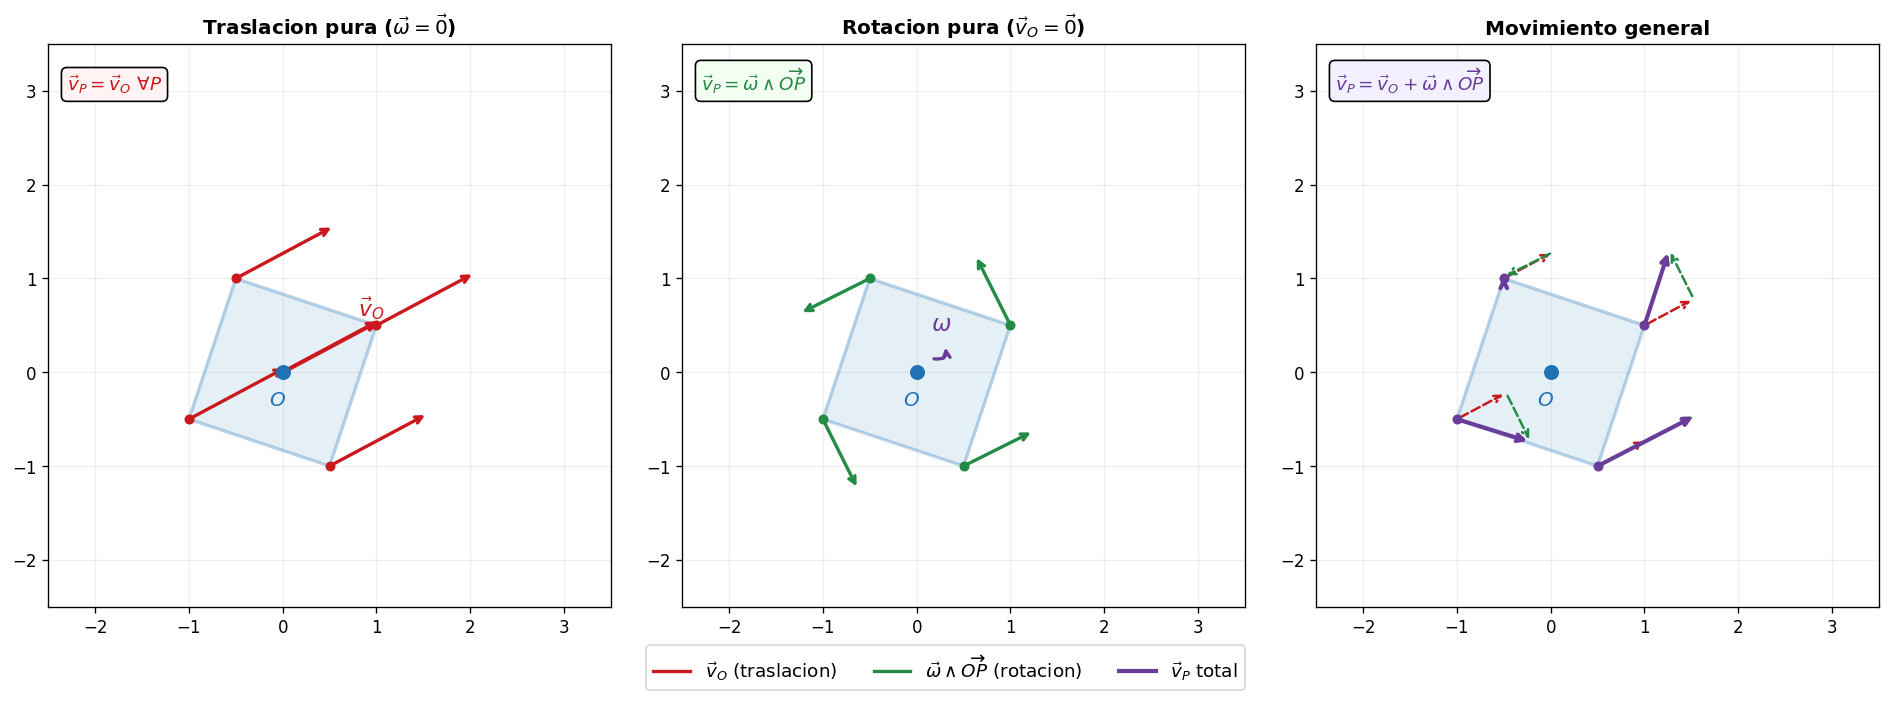

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

for ax in axes:
    ax.set_xlim(-2.5, 3.5)
    ax.set_ylim(-2.5, 3.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

# Datos comunes
O = np.array([0.0, 0.0])
omega = 1.5  # rad/s
vO = np.array([1.5, 0.8])

# Puntos del solido (un cuadrado)
pts_local = np.array([[1, 0.5], [-0.5, 1], [-1, -0.5], [0.5, -1]])

def draw_body(ax, center, pts, color=COLOR_CLARO, ecolor=COLOR_PRINCIPAL):
    body = plt.Polygon(center + pts, closed=True, facecolor=color,
                       edgecolor=ecolor, lw=2, alpha=0.3)
    ax.add_patch(body)
    ax.plot(*center, 'o', color=ecolor, ms=8, zorder=5)
    ax.text(center[0]-0.15, center[1]-0.35, r'$O$', fontsize=12,
            fontweight='bold', color=ecolor)

# ---- Caso 1: Traslacion pura ----
ax1 = axes[0]
ax1.set_title(r'Traslacion pura ($\vec{\omega}=\vec{0}$)', fontsize=12, fontweight='bold')
draw_body(ax1, O, pts_local)
for pt in pts_local:
    P = O + pt
    ax1.annotate('', xy=P + vO*0.7, xytext=P,
                arrowprops=dict(arrowstyle='->', color=COLOR_ROJO, lw=2))
    ax1.plot(*P, 'o', color=COLOR_ROJO, ms=5, zorder=5)
ax1.annotate('', xy=O + vO*0.7, xytext=O,
            arrowprops=dict(arrowstyle='->', color=COLOR_ROJO, lw=2.5))
ax1.text(0.8, 0.6, r'$\vec{v}_O$', fontsize=13, color=COLOR_ROJO, fontweight='bold')
ax1.text(-2.3, 3.0, r'$\vec{v}_P = \vec{v}_O\ \forall P$', fontsize=11,
         color=COLOR_ROJO, bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3f3'))

# ---- Caso 2: Rotacion pura ----
ax2 = axes[1]
ax2.set_title(r'Rotacion pura ($\vec{v}_O=\vec{0}$)', fontsize=12, fontweight='bold')
draw_body(ax2, O, pts_local)
for pt in pts_local:
    P = O + pt
    # omega x OP  (in 2D: [-omega*y, omega*x])
    v_rot = np.array([-omega*pt[1], omega*pt[0]])
    scale = 0.5
    ax2.annotate('', xy=P + v_rot*scale, xytext=P,
                arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=2))
    ax2.plot(*P, 'o', color=COLOR_PUNTO, ms=5, zorder=5)
# Omega symbol
ax2.annotate('', xy=(0.3, 0.3), xytext=(0.15, 0.15),
            arrowprops=dict(arrowstyle='->', color=COLOR_MORADO, lw=2,
                            connectionstyle='arc3,rad=0.8'))
ax2.text(0.15, 0.45, r'$\omega$', fontsize=14, color=COLOR_MORADO, fontweight='bold')
ax2.text(-2.3, 3.0, r'$\vec{v}_P = \vec{\omega} \wedge \overrightarrow{OP}$',
         fontsize=11, color=COLOR_PUNTO,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#f3fff3'))

# ---- Caso 3: General (traslacion + rotacion) ----
ax3 = axes[2]
ax3.set_title('Movimiento general', fontsize=12, fontweight='bold')
draw_body(ax3, O, pts_local)
for pt in pts_local:
    P = O + pt
    v_rot = np.array([-omega*pt[1], omega*pt[0]])
    v_total = vO + v_rot
    scale = 0.35
    # v_O component
    ax3.annotate('', xy=P + vO*scale, xytext=P,
                arrowprops=dict(arrowstyle='->', color=COLOR_ROJO, lw=1.5, linestyle='dashed'))
    # rotation component
    ax3.annotate('', xy=P + vO*scale + v_rot*scale, xytext=P + vO*scale,
                arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=1.5, linestyle='dashed'))
    # total
    ax3.annotate('', xy=P + v_total*scale, xytext=P,
                arrowprops=dict(arrowstyle='->', color=COLOR_MORADO, lw=2.5))
    ax3.plot(*P, 'o', color=COLOR_MORADO, ms=5, zorder=5)

ax3.text(-2.3, 3.0,
         r'$\vec{v}_P = \vec{v}_O + \vec{\omega} \wedge \overrightarrow{OP}$',
         fontsize=11, color=COLOR_MORADO,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#f3f0ff'))

# Leyenda global
legend_elements = [
    Line2D([0],[0], color=COLOR_ROJO, lw=2, label=r'$\vec{v}_O$ (traslacion)'),
    Line2D([0],[0], color=COLOR_PUNTO, lw=2, label=r'$\vec{\omega} \wedge \overrightarrow{OP}$ (rotacion)'),
    Line2D([0],[0], color=COLOR_MORADO, lw=2.5, label=r'$\vec{v}_P$ total'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=11,
           frameon=True, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()

---

## 4. Formulas de Poisson

Sea $\{\vec{i}_2, \vec{j}_2, \vec{k}_2\}$ un triedro solidario al cuerpo 2 (sistema de referencia movil). Como los vectores unitarios tienen modulo constante, podemos aplicar la condicion de rigidez:

Consideramos $\vec{i}_2$ como el vector posicion de un punto del solido a distancia unidad del origen. Aplicando Chasles con $\vec{v}_O = 0$:

$$\boxed{\frac{d\vec{i}_2}{dt} = \vec{\omega}_{21} \wedge \vec{i}_2}$$

$$\boxed{\frac{d\vec{j}_2}{dt} = \vec{\omega}_{21} \wedge \vec{j}_2}$$

$$\boxed{\frac{d\vec{k}_2}{dt} = \vec{\omega}_{21} \wedge \vec{k}_2}$$

### Interpretacion

Las **formulas de Poisson** expresan como cambian los vectores unitarios del triedro movil para un observador en el sistema fijo. Cada vector unitario "gira" alrededor de $\vec{\omega}_{21}$ con velocidad angular $|\vec{\omega}_{21}|$.

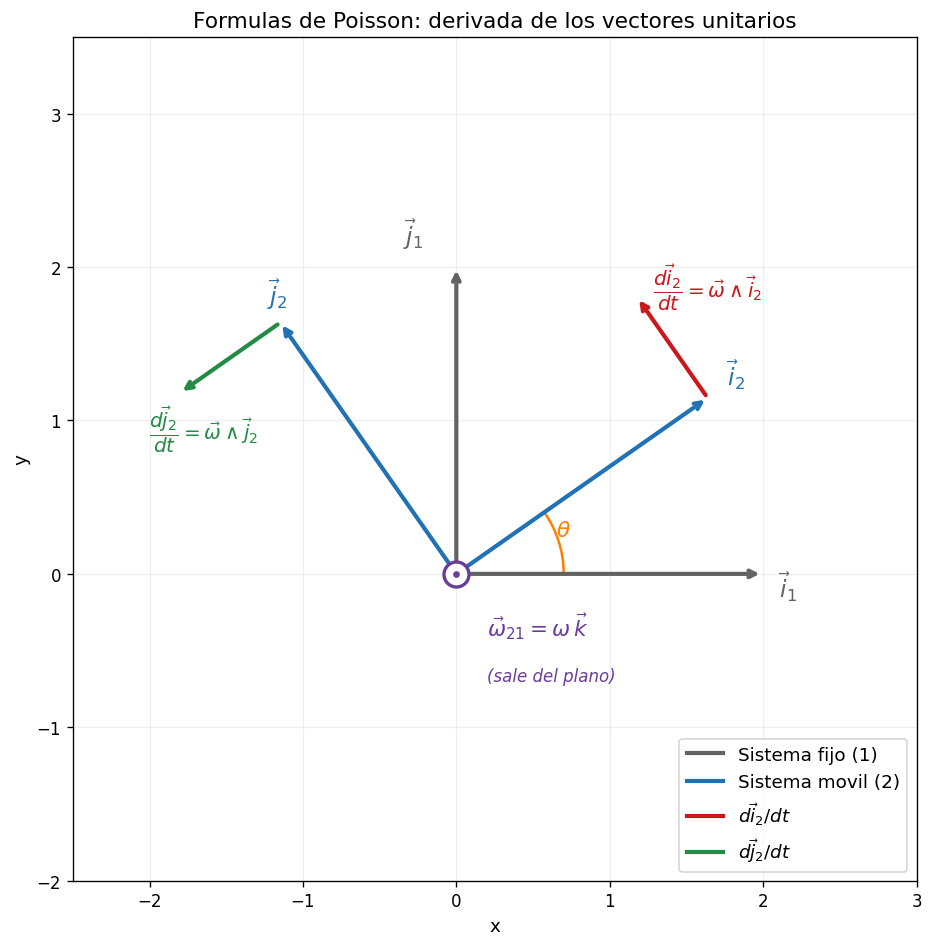

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.set_xlim(-2.5, 3.0)
ax.set_ylim(-2.0, 3.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)
ax.set_title('Formulas de Poisson: derivada de los vectores unitarios', fontsize=13)

O = np.array([0.0, 0.0])

# Sistema fijo
ax.annotate('', xy=(2.0, 0), xytext=O,
            arrowprops=dict(arrowstyle='->', color=COLOR_FIJO, lw=2.5))
ax.annotate('', xy=(0, 2.0), xytext=O,
            arrowprops=dict(arrowstyle='->', color=COLOR_FIJO, lw=2.5))
ax.text(2.1, -0.15, r'$\vec{i}_1$', fontsize=14, color=COLOR_FIJO, fontweight='bold')
ax.text(-0.35, 2.15, r'$\vec{j}_1$', fontsize=14, color=COLOR_FIJO, fontweight='bold')

# Sistema movil (rotado theta)
theta = np.radians(35)
i2 = np.array([np.cos(theta), np.sin(theta)])
j2 = np.array([-np.sin(theta), np.cos(theta)])

ax.annotate('', xy=2.0*i2, xytext=O,
            arrowprops=dict(arrowstyle='->', color=COLOR_PRINCIPAL, lw=2.5))
ax.annotate('', xy=2.0*j2, xytext=O,
            arrowprops=dict(arrowstyle='->', color=COLOR_PRINCIPAL, lw=2.5))
ax.text(*(2.15*i2), r'$\vec{i}_2$', fontsize=14, color=COLOR_PRINCIPAL, fontweight='bold')
ax.text(*(2.15*j2), r'$\vec{j}_2$', fontsize=14, color=COLOR_PRINCIPAL, fontweight='bold')

# Arco mostrando theta
arc_angles = np.linspace(0, theta, 30)
r_arc = 0.7
ax.plot(r_arc*np.cos(arc_angles), r_arc*np.sin(arc_angles),
        '-', color=COLOR_NARANJA, lw=1.5)
ax.text(0.65, 0.25, r'$\theta$', fontsize=13, color=COLOR_NARANJA)

# di2/dt = omega x i2  (perpendicular a i2)
di2 = np.array([-np.sin(theta), np.cos(theta)])  # omega x i2
tip_i2 = 2.0*i2
ax.annotate('', xy=tip_i2 + 0.8*di2, xytext=tip_i2,
            arrowprops=dict(arrowstyle='->', color=COLOR_ROJO, lw=2.5))
ax.text(tip_i2[0] + 0.8*di2[0] + 0.1, tip_i2[1] + 0.8*di2[1],
        r'$\dfrac{d\vec{i}_2}{dt} = \vec{\omega} \wedge \vec{i}_2$',
        fontsize=12, color=COLOR_ROJO, fontweight='bold')

# dj2/dt = omega x j2  (perpendicular a j2, pointing -i2 direction)
dj2 = np.array([-np.cos(theta), -np.sin(theta)])  # omega x j2 = -i2
tip_j2 = 2.0*j2
ax.annotate('', xy=tip_j2 + 0.8*dj2, xytext=tip_j2,
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=2.5))
ax.text(tip_j2[0] + 0.8*dj2[0] - 0.2, tip_j2[1] + 0.8*dj2[1] - 0.3,
        r'$\dfrac{d\vec{j}_2}{dt} = \vec{\omega} \wedge \vec{j}_2$',
        fontsize=12, color=COLOR_PUNTO, fontweight='bold')

# Omega symbol (out of plane)
ax.plot(0, 0, 'o', ms=15, color='white', markeredgecolor=COLOR_MORADO,
        markeredgewidth=2, zorder=10)
ax.plot(0, 0, '.', ms=6, color=COLOR_MORADO, zorder=11)
ax.text(0.2, -0.4, r'$\vec{\omega}_{21} = \omega\,\vec{k}$', fontsize=13,
        color=COLOR_MORADO, fontweight='bold')
ax.text(0.2, -0.7, '(sale del plano)', fontsize=10, color=COLOR_MORADO, fontstyle='italic')

# Leyenda
legend_elements = [
    Line2D([0],[0], color=COLOR_FIJO, lw=2.5, label='Sistema fijo (1)'),
    Line2D([0],[0], color=COLOR_PRINCIPAL, lw=2.5, label='Sistema movil (2)'),
    Line2D([0],[0], color=COLOR_ROJO, lw=2.5, label=r'$d\vec{i}_2/dt$'),
    Line2D([0],[0], color=COLOR_PUNTO, lw=2.5, label=r'$d\vec{j}_2/dt$'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
plt.show()

---

## 5. Derivada de un vector en ejes moviles

Sea un vector $\vec{A}$ expresado en componentes del sistema movil 2:

$$\vec{A} = A_1 \vec{i}_2 + A_2 \vec{j}_2 + A_3 \vec{k}_2$$

Su derivada temporal vista desde el sistema fijo 1:

$$\left.\frac{d\vec{A}}{dt}\right|_1 = \dot{A}_1 \vec{i}_2 + \dot{A}_2 \vec{j}_2 + \dot{A}_3 \vec{k}_2 + A_1 \frac{d\vec{i}_2}{dt} + A_2 \frac{d\vec{j}_2}{dt} + A_3 \frac{d\vec{k}_2}{dt}$$

Usando las formulas de Poisson:

$$\left.\frac{d\vec{A}}{dt}\right|_1 = \underbrace{\dot{A}_1 \vec{i}_2 + \dot{A}_2 \vec{j}_2 + \dot{A}_3 \vec{k}_2}_{\left.\frac{d\vec{A}}{dt}\right|_2} + \vec{\omega}_{21} \wedge \underbrace{(A_1 \vec{i}_2 + A_2 \vec{j}_2 + A_3 \vec{k}_2)}_{\vec{A}}$$

$$\boxed{\left.\frac{d\vec{A}}{dt}\right|_1 = \left.\frac{d\vec{A}}{dt}\right|_2 + \vec{\omega}_{21} \wedge \vec{A}}$$

> **Interpretacion**: La derivada absoluta = derivada relativa (cambio de componentes) + arrastre (rotacion del triedro).

**Nota**: Si $\vec{A}$ es solidario al cuerpo 2 (componentes constantes en 2): $\left.\frac{d\vec{A}}{dt}\right|_2 = \vec{0}$, y se recupera la formula de Chasles.

---

## 6. Condicion de rigidez en aceleraciones

Derivando la expresion de Chasles:

$$\vec{v}_{21}^P = \vec{v}_{21}^O + \vec{\omega}_{21} \wedge \overrightarrow{OP}$$

$$\vec{a}_{21}^P = \vec{a}_{21}^O + \frac{d\vec{\omega}_{21}}{dt} \wedge \overrightarrow{OP} + \vec{\omega}_{21} \wedge \frac{d\overrightarrow{OP}}{dt}$$

Dado que $\overrightarrow{OP}$ es solidario al solido: $\frac{d\overrightarrow{OP}}{dt} = \vec{\omega}_{21} \wedge \overrightarrow{OP}$

$$\boxed{\vec{a}_{21}^P = \vec{a}_{21}^O + \vec{\alpha}_{21} \wedge \overrightarrow{OP} + \vec{\omega}_{21} \wedge (\vec{\omega}_{21} \wedge \overrightarrow{OP})}$$

donde $\vec{\alpha}_{21} = \frac{d\vec{\omega}_{21}}{dt}$ es la **aceleracion angular**.

### Descomposicion de la aceleracion

| Termino | Nombre | Direccion |
|---------|--------|----------|
| $\vec{a}_{21}^O$ | Aceleracion del punto de referencia | Depende del problema |
| $\vec{\alpha}_{21} \wedge \overrightarrow{OP}$ | **Aceleracion tangencial** | Perpendicular a $\overrightarrow{OP}$ |
| $\vec{\omega}_{21} \wedge (\vec{\omega}_{21} \wedge \overrightarrow{OP})$ | **Aceleracion centripeta** | Dirigida de $P$ hacia $O$ |

### Caso plano

En movimiento plano, usando la identidad BAC-CAB: $\vec{\omega} \wedge (\vec{\omega} \wedge \overrightarrow{OP}) = -\omega^2 \overrightarrow{OP}$

$$\boxed{\vec{a}_{21}^P = \vec{a}_{21}^O + \vec{\alpha}_{21} \wedge \overrightarrow{OP} - \omega_{21}^2 \overrightarrow{OP}}$$

---

## 7. Movimiento relativo - Velocidades

Consideremos tres cuerpos (o sistemas de referencia): 1, 2 y 3. Para un punto $P$:

- $\vec{v}_{31}^P$: velocidad de $P$ del cuerpo 3 vista desde 1 (**velocidad absoluta**)
- $\vec{v}_{32}^P$: velocidad de $P$ del cuerpo 3 vista desde 2 (**velocidad relativa**)
- $\vec{v}_{21}^P$: velocidad del punto de 2 coincidente con $P$ vista desde 1 (**velocidad de arrastre**)

La composicion de velocidades establece:

$$\boxed{\vec{v}_{31}^P = \vec{v}_{32}^P + \vec{v}_{21}^P}$$

O equivalentemente: **velocidad absoluta = velocidad relativa + velocidad de arrastre**.

### Generalizacion

La composicion se extiende a cualquier numero de cuerpos intermedios. Por ejemplo, con 4 cuerpos:

$$\vec{v}_{41}^P = \vec{v}_{43}^P + \vec{v}_{32}^P + \vec{v}_{21}^P$$

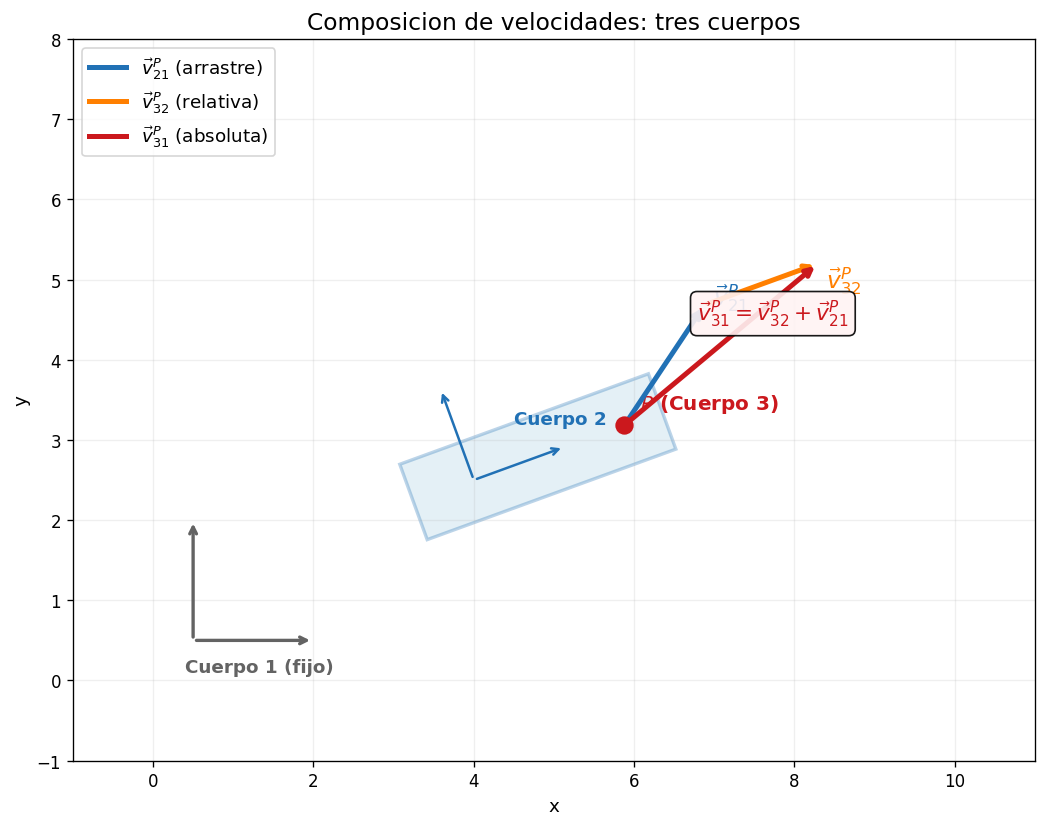

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(12, 7))
ax.set_xlim(-1, 11)
ax.set_ylim(-1, 8)
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)
ax.set_title('Composicion de velocidades: tres cuerpos', fontsize=14)

# --- Cuerpo 1 (fijo/suelo) ---
O1 = np.array([0.5, 0.5])
ax.annotate('', xy=O1 + np.array([1.5, 0]), xytext=O1,
            arrowprops=dict(arrowstyle='->', color=COLOR_FIJO, lw=2))
ax.annotate('', xy=O1 + np.array([0, 1.5]), xytext=O1,
            arrowprops=dict(arrowstyle='->', color=COLOR_FIJO, lw=2))
ax.text(O1[0]-0.1, O1[1]-0.4, 'Cuerpo 1 (fijo)', fontsize=11, color=COLOR_FIJO,
        fontweight='bold')

# --- Cuerpo 2 (intermedio) ---
O2 = np.array([4.0, 2.5])
th2 = np.radians(20)
i2 = np.array([np.cos(th2), np.sin(th2)])
j2 = np.array([-np.sin(th2), np.cos(th2)])
# Draw body 2 as a rectangle
rect2_pts = np.array([O2 - 0.8*i2 - 0.5*j2, O2 + 2.5*i2 - 0.5*j2,
                       O2 + 2.5*i2 + 0.5*j2, O2 - 0.8*i2 + 0.5*j2])
body2 = plt.Polygon(rect2_pts, closed=True, facecolor=COLOR_CLARO,
                    edgecolor=COLOR_PRINCIPAL, lw=2, alpha=0.3)
ax.add_patch(body2)
ax.text(O2[0]+0.5, O2[1]+0.7, 'Cuerpo 2', fontsize=11, color=COLOR_PRINCIPAL,
        fontweight='bold')
# Axes of body 2
ax.annotate('', xy=O2 + 1.2*i2, xytext=O2,
            arrowprops=dict(arrowstyle='->', color=COLOR_PRINCIPAL, lw=1.5))
ax.annotate('', xy=O2 + 1.2*j2, xytext=O2,
            arrowprops=dict(arrowstyle='->', color=COLOR_PRINCIPAL, lw=1.5))

# --- Cuerpo 3 (movil sobre 2) ---
P = O2 + 2.0*i2 + 0.0*j2
ax.plot(*P, 'o', color=COLOR_ROJO, ms=10, zorder=6)
ax.text(P[0]+0.2, P[1]+0.2, r'$P$ (Cuerpo 3)', fontsize=12,
        color=COLOR_ROJO, fontweight='bold')

# --- Vectores de velocidad ---
# v_21^P (arrastre)
v21 = np.array([1.0, 1.5])
ax.annotate('', xy=P + v21, xytext=P,
            arrowprops=dict(arrowstyle='->', color=COLOR_PRINCIPAL, lw=3))
ax.text(P[0]+v21[0]+0.1, P[1]+v21[1], r'$\vec{v}_{21}^P$', fontsize=14,
        color=COLOR_PRINCIPAL, fontweight='bold')

# v_32^P (relativa)
v32 = 1.5*i2
ax.annotate('', xy=P + v21 + v32, xytext=P + v21,
            arrowprops=dict(arrowstyle='->', color=COLOR_NARANJA, lw=3))
ax.text(P[0]+v21[0]+v32[0]+0.1, P[1]+v21[1]+v32[1]-0.3, r'$\vec{v}_{32}^P$',
        fontsize=14, color=COLOR_NARANJA, fontweight='bold')

# v_31^P (absoluta)
v31 = v21 + v32
ax.annotate('', xy=P + v31, xytext=P,
            arrowprops=dict(arrowstyle='->', color=COLOR_ROJO, lw=3))
ax.text(P[0]+v31[0]*0.5-0.3, P[1]+v31[1]*0.5+0.3,
        r'$\vec{v}_{31}^P = \vec{v}_{32}^P + \vec{v}_{21}^P$',
        fontsize=13, color=COLOR_ROJO, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3f3', alpha=0.9))

# Leyenda
legend_elements = [
    Line2D([0],[0], color=COLOR_PRINCIPAL, lw=3, label=r'$\vec{v}_{21}^P$ (arrastre)'),
    Line2D([0],[0], color=COLOR_NARANJA, lw=3, label=r'$\vec{v}_{32}^P$ (relativa)'),
    Line2D([0],[0], color=COLOR_ROJO, lw=3, label=r'$\vec{v}_{31}^P$ (absoluta)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11)

ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
plt.show()

---

## 8. Movimiento relativo - Velocidades angulares

Las velocidades angulares tambien se componen por suma vectorial:

$$\boxed{\vec{\omega}_{31} = \vec{\omega}_{32} + \vec{\omega}_{21}}$$

### Propiedad de indices

La regla general es que los indices intermedios se "cancelan":

$$\vec{\omega}_{ij} = \vec{\omega}_{ik} + \vec{\omega}_{kj}$$

### Propiedad antisimetrica

$$\vec{\omega}_{ij} = -\vec{\omega}_{ji}$$

### Ejemplo con multiples cuerpos

Para un tren de engranajes con 4 ruedas:

$$\vec{\omega}_{41} = \vec{\omega}_{43} + \vec{\omega}_{32} + \vec{\omega}_{21}$$

---

## 9. Movimiento relativo - Aceleraciones

La composicion de aceleraciones introduce un termino adicional respecto a la de velocidades:

$$\boxed{\vec{a}_{31}^P = \vec{a}_{32}^P + \vec{a}_{21}^P + 2\vec{\omega}_{21} \wedge \vec{v}_{32}^P}$$

El termino adicional $2\vec{\omega}_{21} \wedge \vec{v}_{32}^P$ es la **aceleracion de Coriolis**.

### Desglose de cada termino

| Termino | Nombre | Descripcion |
|---------|--------|-------------|
| $\vec{a}_{31}^P$ | Aceleracion absoluta | Aceleracion de $P$ del cuerpo 3 vista desde 1 |
| $\vec{a}_{32}^P$ | Aceleracion relativa | Aceleracion de $P$ del cuerpo 3 vista desde 2 |
| $\vec{a}_{21}^P$ | Aceleracion de arrastre | Aceleracion del punto de 2 coincidente con $P$ vista desde 1 |
| $2\vec{\omega}_{21} \wedge \vec{v}_{32}^P$ | **Aceleracion de Coriolis** | Aparece cuando hay rotacion relativa Y velocidad relativa |

### Composicion de aceleraciones angulares

$$\boxed{\vec{\alpha}_{ij} = \vec{\alpha}_{ik} + \vec{\alpha}_{kj}}$$

**Atencion**: la aceleracion angular se compone por suma directa (sin termino de Coriolis), pero solo en el caso plano. En el caso espacial hay un termino adicional $\vec{\omega}_{21} \wedge \vec{\omega}_{32}$.

### Cuando aparece Coriolis?

La aceleracion de Coriolis es **no nula** cuando se cumplen simultaneamente:
1. El cuerpo 2 **rota** respecto a 1 ($\vec{\omega}_{21} \neq \vec{0}$)
2. El punto $P$ del cuerpo 3 tiene **velocidad relativa** respecto a 2 ($\vec{v}_{32}^P \neq \vec{0}$)

Su direccion es **perpendicular** tanto a $\vec{\omega}_{21}$ como a $\vec{v}_{32}^P$.

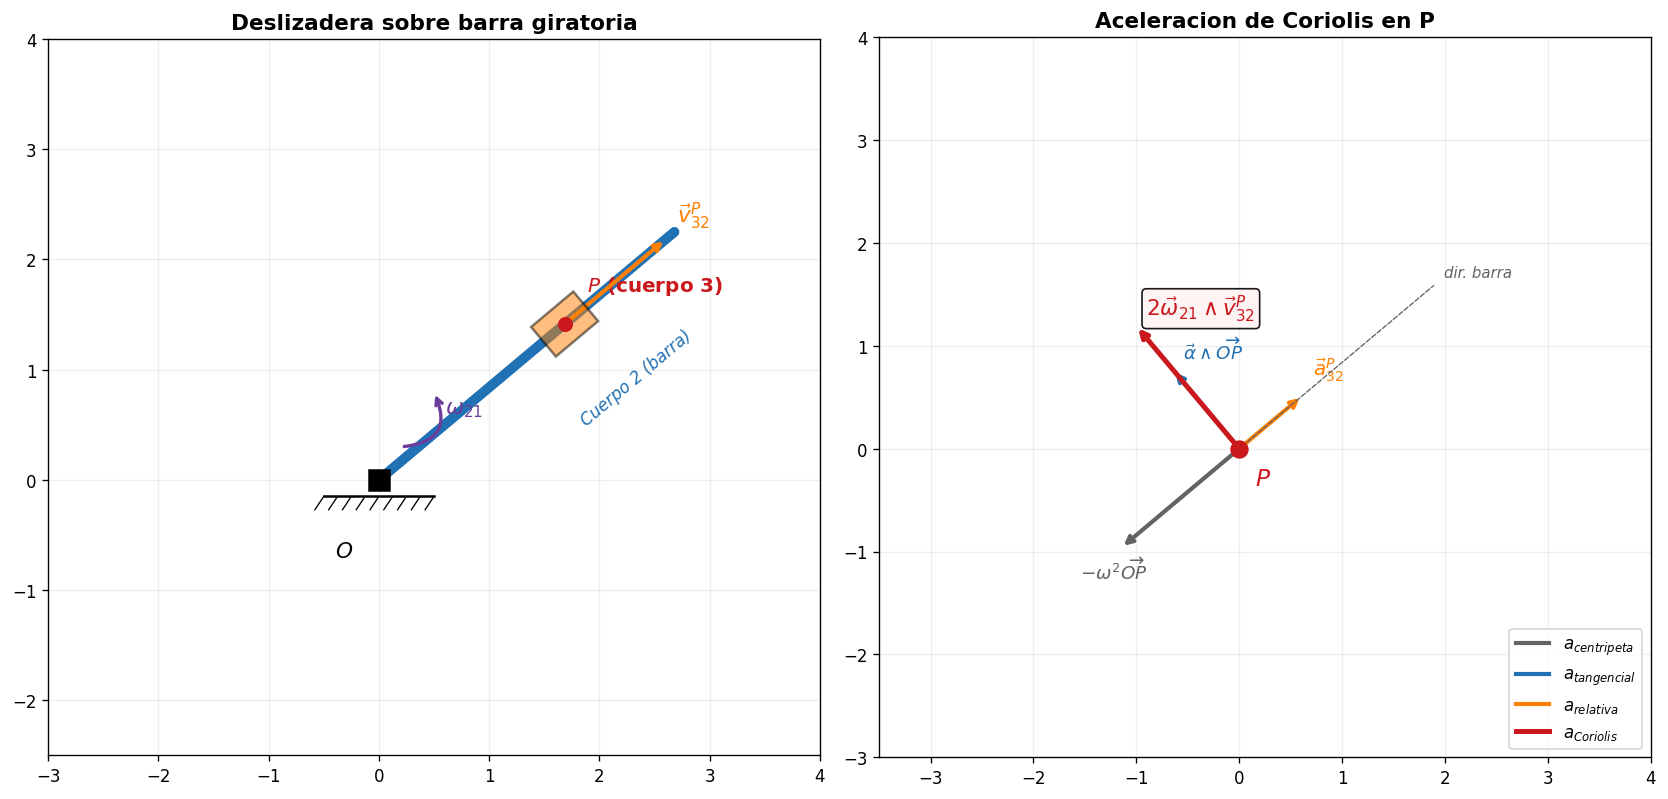

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))

# ---- Panel izquierdo: Esquema fisico ----
ax1 = axes[0]
ax1.set_xlim(-3, 4)
ax1.set_ylim(-2.5, 4)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.2)
ax1.set_title('Deslizadera sobre barra giratoria', fontsize=13, fontweight='bold')

# Barra giratoria (cuerpo 2)
theta_bar = np.radians(40)
L = 3.5
O_bar = np.array([0.0, 0.0])
B_bar = O_bar + L*np.array([np.cos(theta_bar), np.sin(theta_bar)])
draw_link(ax1, O_bar, B_bar, color=COLOR_PRINCIPAL, lw=6)
draw_joint(ax1, O_bar, fixed=True, ms=12)
draw_ground(ax1, O_bar, 1.0)
ax1.text(-0.4, -0.7, r'$O$', fontsize=13, fontweight='bold')

# Omega de la barra
ax1.annotate('', xy=(0.5, 0.8), xytext=(0.2, 0.3),
            arrowprops=dict(arrowstyle='->', color=COLOR_MORADO, lw=2,
                            connectionstyle='arc3,rad=0.7'))
ax1.text(0.6, 0.6, r'$\omega_{21}$', fontsize=13, color=COLOR_MORADO, fontweight='bold')

# Slider (cuerpo 3) en punto P sobre la barra
r_P = 2.2
dir_bar = np.array([np.cos(theta_bar), np.sin(theta_bar)])
perp_bar = np.array([-np.sin(theta_bar), np.cos(theta_bar)])
P = O_bar + r_P * dir_bar

# Draw slider as rectangle
slider_w, slider_h = 0.5, 0.35
corners = np.array([
    P - slider_w/2*dir_bar - slider_h/2*perp_bar,
    P + slider_w/2*dir_bar - slider_h/2*perp_bar,
    P + slider_w/2*dir_bar + slider_h/2*perp_bar,
    P - slider_w/2*dir_bar + slider_h/2*perp_bar,
])
slider = plt.Polygon(corners, closed=True, facecolor=COLOR_NARANJA,
                     edgecolor='black', lw=1.5, alpha=0.5, zorder=4)
ax1.add_patch(slider)
ax1.plot(*P, 'o', color=COLOR_ROJO, ms=8, zorder=6)
ax1.text(P[0]+0.2, P[1]+0.3, r'$P$ (cuerpo 3)', fontsize=12,
        color=COLOR_ROJO, fontweight='bold')

# v_32 (velocity of slider along bar)
v32_mag = 1.2
v32 = v32_mag * dir_bar
ax1.annotate('', xy=P + v32, xytext=P,
            arrowprops=dict(arrowstyle='->', color=COLOR_NARANJA, lw=2.5))
ax1.text(P[0]+v32[0]+0.1, P[1]+v32[1]+0.15, r'$\vec{v}_{32}^P$', fontsize=13,
        color=COLOR_NARANJA, fontweight='bold')

# Labels
ax1.text(1.8, 0.5, 'Cuerpo 2 (barra)', fontsize=10, color=COLOR_PRINCIPAL,
        fontstyle='italic', rotation=np.degrees(theta_bar))

# ---- Panel derecho: Vectores de aceleracion ----
ax2 = axes[1]
ax2.set_xlim(-3.5, 4)
ax2.set_ylim(-3, 4)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.2)
ax2.set_title('Aceleracion de Coriolis en P', fontsize=13, fontweight='bold')

P2 = np.array([0.0, 0.0])  # P como referencia
ax2.plot(*P2, 'o', color=COLOR_ROJO, ms=10, zorder=6)
ax2.text(0.15, -0.35, r'$P$', fontsize=14, color=COLOR_ROJO, fontweight='bold')

# a_arrastre (centripeta + tangencial)
omega_val = 2.0
alpha_val = 1.0

# Centripetal: -omega^2 * OP (towards O)
a_cent_dir = -dir_bar
a_cent = 1.5 * a_cent_dir
ax2.annotate('', xy=P2 + a_cent, xytext=P2,
            arrowprops=dict(arrowstyle='->', color=COLOR_FIJO, lw=2.5))
ax2.text(P2[0]+a_cent[0]-0.4, P2[1]+a_cent[1]-0.3,
        r'$-\omega^2 \overrightarrow{OP}$', fontsize=11, color=COLOR_FIJO)

# Tangential: alpha x OP (perpendicular to bar)
a_tang = 1.0 * perp_bar
ax2.annotate('', xy=P2 + a_tang, xytext=P2,
            arrowprops=dict(arrowstyle='->', color=COLOR_PRINCIPAL, lw=2.5))
ax2.text(P2[0]+a_tang[0]+0.1, P2[1]+a_tang[1]+0.1,
        r'$\vec{\alpha} \wedge \overrightarrow{OP}$', fontsize=11, color=COLOR_PRINCIPAL)

# Relative acceleration a_32
a_rel = 0.8 * dir_bar
ax2.annotate('', xy=P2 + a_rel, xytext=P2,
            arrowprops=dict(arrowstyle='->', color=COLOR_NARANJA, lw=2.5))
ax2.text(P2[0]+a_rel[0]+0.1, P2[1]+a_rel[1]+0.2,
        r'$\vec{a}_{32}^P$', fontsize=12, color=COLOR_NARANJA, fontweight='bold')

# CORIOLIS: 2*omega x v_32 (perpendicular to v_32 = perpendicular to bar)
a_cor = 1.2 * perp_bar
ax2.annotate('', xy=P2 + a_cor*1.3, xytext=P2,
            arrowprops=dict(arrowstyle='->', color=COLOR_ROJO, lw=3))
ax2.text(P2[0]+a_cor[0]*1.3+0.1, P2[1]+a_cor[1]*1.3+0.1,
        r'$2\vec{\omega}_{21} \wedge \vec{v}_{32}^P$', fontsize=13,
        color=COLOR_ROJO, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#fff3f3', alpha=0.9))

# Direction labels
ax2.annotate('', xy=P2 + 2.5*dir_bar, xytext=P2,
            arrowprops=dict(arrowstyle='-', color=COLOR_FIJO, lw=0.8, linestyle='dashed'))
ax2.text(P2[0]+2.6*dir_bar[0], P2[1]+2.6*dir_bar[1],
        'dir. barra', fontsize=9, color=COLOR_FIJO, fontstyle='italic')

# Leyenda
legend_elements = [
    Line2D([0],[0], color=COLOR_FIJO, lw=2.5, label=r'$a_{centripeta}$'),
    Line2D([0],[0], color=COLOR_PRINCIPAL, lw=2.5, label=r'$a_{tangencial}$'),
    Line2D([0],[0], color=COLOR_NARANJA, lw=2.5, label=r'$a_{relativa}$'),
    Line2D([0],[0], color=COLOR_ROJO, lw=3, label=r'$a_{Coriolis}$'),
]
ax2.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

---

## 10. Ejercicios resueltos

### Ejercicio 1: Velocidades en una barra en rotacion

Una barra $OA$ de longitud $L = 0.5$ m gira alrededor de $O$ con $\omega_{21} = 4$ rad/s y $\alpha_{21} = 2$ rad/s$^2$. Calcular la velocidad y aceleracion del extremo $A$.

**Datos**: $O$ fijo, $L = 0.5$ m, $\omega = 4$ rad/s, $\alpha = 2$ rad/s$^2$, $\theta = 30°$.

**Solucion**:

Como $O$ es fijo: $\vec{v}_{21}^O = \vec{0}$ y $\vec{a}_{21}^O = \vec{0}$

**Velocidad de A** (Chasles):

$$\vec{v}_A = \vec{\omega} \wedge \overrightarrow{OA} = \omega \cdot L = 4 \times 0.5 = 2 \text{ m/s}$$

Direccion: perpendicular a $OA$.

**Aceleracion de A**:

$$a_t = \alpha \cdot L = 2 \times 0.5 = 1 \text{ m/s}^2 \quad \text{(tangencial)}$$

$$a_n = \omega^2 \cdot L = 16 \times 0.5 = 8 \text{ m/s}^2 \quad \text{(centripeta)}$$

$$|\vec{a}_A| = \sqrt{a_t^2 + a_n^2} = \sqrt{1 + 64} = \sqrt{65} \approx 8.06 \text{ m/s}^2$$

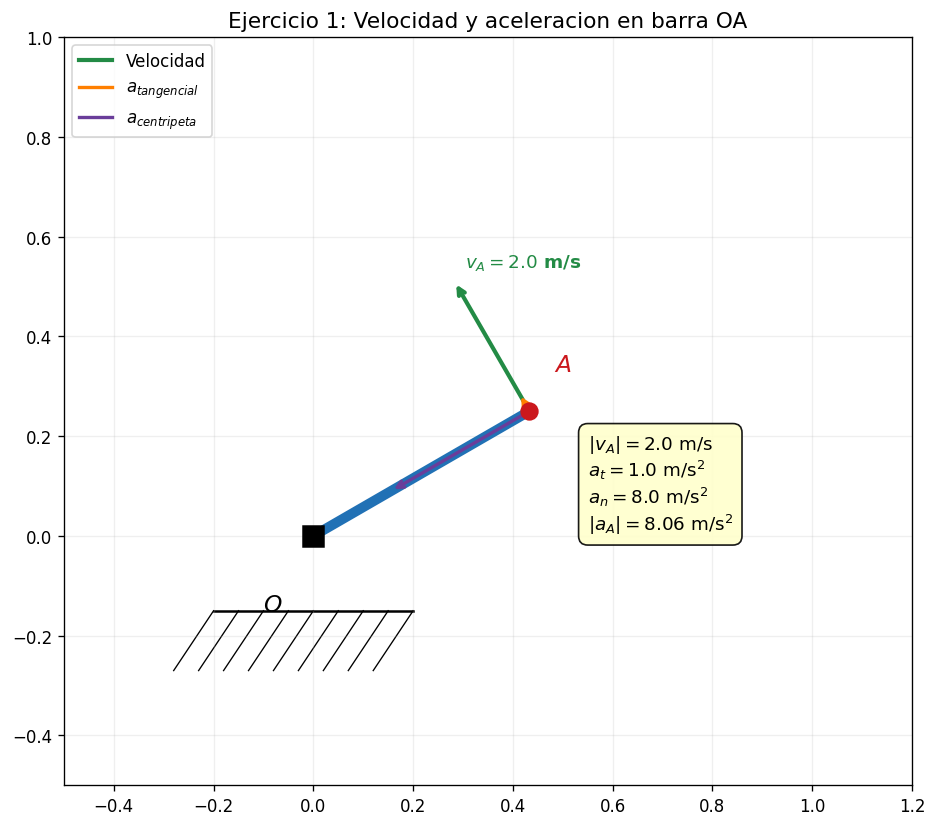

In [7]:
# --- Ejercicio 1: Velocidad y aceleracion del extremo de una barra ---
L = 0.5      # m
omega = 4.0  # rad/s
alpha = 2.0  # rad/s^2
theta = np.radians(30)

# Velocidad
v_A = omega * L

# Aceleracion
a_tang = alpha * L
a_cent = omega**2 * L
a_total = np.sqrt(a_tang**2 + a_cent**2)

# --- Visualizacion ---
fig, ax = plt.subplots(1, 1, figsize=(8, 7))
ax.set_xlim(-0.5, 1.2)
ax.set_ylim(-0.5, 1.0)
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)
ax.set_title('Ejercicio 1: Velocidad y aceleracion en barra OA', fontsize=13)

O_pos = np.array([0, 0])
A_pos = O_pos + L * np.array([np.cos(theta), np.sin(theta)])
dir_OA = np.array([np.cos(theta), np.sin(theta)])
perp_OA = np.array([-np.sin(theta), np.cos(theta)])

# Barra
draw_link(ax, O_pos, A_pos, color=COLOR_PRINCIPAL, lw=6)
draw_joint(ax, O_pos, fixed=True, ms=12)
draw_ground(ax, O_pos, 0.4)
ax.text(-0.1, -0.15, r'$O$', fontsize=14, fontweight='bold')
ax.plot(*A_pos, 'o', color=COLOR_ROJO, ms=10, zorder=6)
ax.text(A_pos[0]+0.05, A_pos[1]+0.08, r'$A$', fontsize=14, fontweight='bold', color=COLOR_ROJO)

# Velocidad (perpendicular a OA)
scale_v = 0.15
v_vec = v_A * perp_OA * scale_v
ax.annotate('', xy=A_pos + v_vec, xytext=A_pos,
            arrowprops=dict(arrowstyle='->', color=COLOR_PUNTO, lw=2.5))
ax.text(A_pos[0]+v_vec[0]+0.02, A_pos[1]+v_vec[1]+0.03,
        f'$v_A = {v_A}$ m/s', fontsize=11, color=COLOR_PUNTO, fontweight='bold')

# Aceleracion tangencial
scale_a = 0.04
at_vec = a_tang * perp_OA * scale_a
ax.annotate('', xy=A_pos + at_vec, xytext=A_pos,
            arrowprops=dict(arrowstyle='->', color=COLOR_NARANJA, lw=2))

# Aceleracion centripeta (hacia O)
an_vec = -a_cent * dir_OA * scale_a
ax.annotate('', xy=A_pos + an_vec, xytext=A_pos,
            arrowprops=dict(arrowstyle='->', color=COLOR_MORADO, lw=2))

# Resultados box
results_text = (f'$|v_A| = {v_A}$ m/s\n'
                f'$a_t = {a_tang}$ m/s$^2$\n'
                f'$a_n = {a_cent}$ m/s$^2$\n'
                f'$|a_A| = {a_total:.2f}$ m/s$^2$')
ax.text(0.55, 0.0, results_text, fontsize=11,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffffcc', alpha=0.9),
        verticalalignment='bottom')

legend_elements = [
    Line2D([0],[0], color=COLOR_PUNTO, lw=2.5, label='Velocidad'),
    Line2D([0],[0], color=COLOR_NARANJA, lw=2, label=r'$a_{tangencial}$'),
    Line2D([0],[0], color=COLOR_MORADO, lw=2, label=r'$a_{centripeta}$'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

### Ejercicio 2: Derivada de un vector en ejes moviles

Un disco gira con $\omega_{21} = 3$ rad/s (constante). Un vector $\vec{A}$ expresado en el sistema movil tiene componentes $\vec{A} = (2t)\vec{i}_2 + (3)\vec{j}_2$. Calcular $\left.\frac{d\vec{A}}{dt}\right|_1$ en $t = 1$ s cuando el disco esta en $\theta = 0$.

**Solucion**:

En $t = 1$ s, $\theta = \omega \cdot t = 3$ rad, $\vec{A} = 2\vec{i}_2 + 3\vec{j}_2$

$$\left.\frac{d\vec{A}}{dt}\right|_2 = \dot{A}_1 \vec{i}_2 + \dot{A}_2 \vec{j}_2 = 2\vec{i}_2 + 0\vec{j}_2 = 2\vec{i}_2$$

$$\vec{\omega}_{21} \wedge \vec{A} = 3\vec{k} \wedge (2\vec{i}_2 + 3\vec{j}_2) = 6\vec{j}_2 - 9\vec{i}_2$$

$$\left.\frac{d\vec{A}}{dt}\right|_1 = (2 - 9)\vec{i}_2 + (0 + 6)\vec{j}_2 = -7\vec{i}_2 + 6\vec{j}_2$$

$$\left|\frac{d\vec{A}}{dt}\right|_1 = \sqrt{49 + 36} = \sqrt{85} \approx 9.22$$

### Ejercicio 3: Aceleracion de Coriolis - deslizadera sobre barra giratoria

Una barra $OB$ gira alrededor de $O$ con $\omega_{21} = 5$ rad/s (constante, $\alpha_{21} = 0$). Una deslizadera $P$ (cuerpo 3) se mueve a lo largo de la barra con velocidad relativa $v_{32} = 0.4$ m/s y aceleracion relativa $a_{32} = 0.1$ m/s$^2$ (ambas hacia fuera). En el instante analizado, $P$ esta a $r = 0.3$ m de $O$ y $\theta = 45°$.

Calcular la aceleracion absoluta $\vec{a}_{31}^P$.

**Solucion**:

Usando $\vec{a}_{31}^P = \vec{a}_{32}^P + \vec{a}_{21}^P + 2\vec{\omega}_{21} \wedge \vec{v}_{32}^P$:

1. **Aceleracion relativa**: $\vec{a}_{32}^P = 0.1 \vec{u}_r$ (a lo largo de la barra)

2. **Aceleracion de arrastre**:
   - Tangencial: $\alpha \times r = 0$ (omega constante)
   - Centripeta: $\omega^2 \times r = 25 \times 0.3 = 7.5$ m/s$^2$ (hacia $O$)
   - $\vec{a}_{21}^P = -7.5\vec{u}_r$

3. **Coriolis**: $2\omega_{21} \cdot v_{32} = 2 \times 5 \times 0.4 = 4.0$ m/s$^2$ (perpendicular a la barra)

Componentes en el sistema de la barra ($\vec{u}_r$, $\vec{u}_\theta$):
- Radial: $a_r = 0.1 - 7.5 = -7.4$ m/s$^2$
- Tangencial: $a_\theta = 0 + 4.0 = 4.0$ m/s$^2$
- $|\vec{a}_{31}^P| = \sqrt{7.4^2 + 4.0^2} = \sqrt{70.76} \approx 8.41$ m/s$^2$

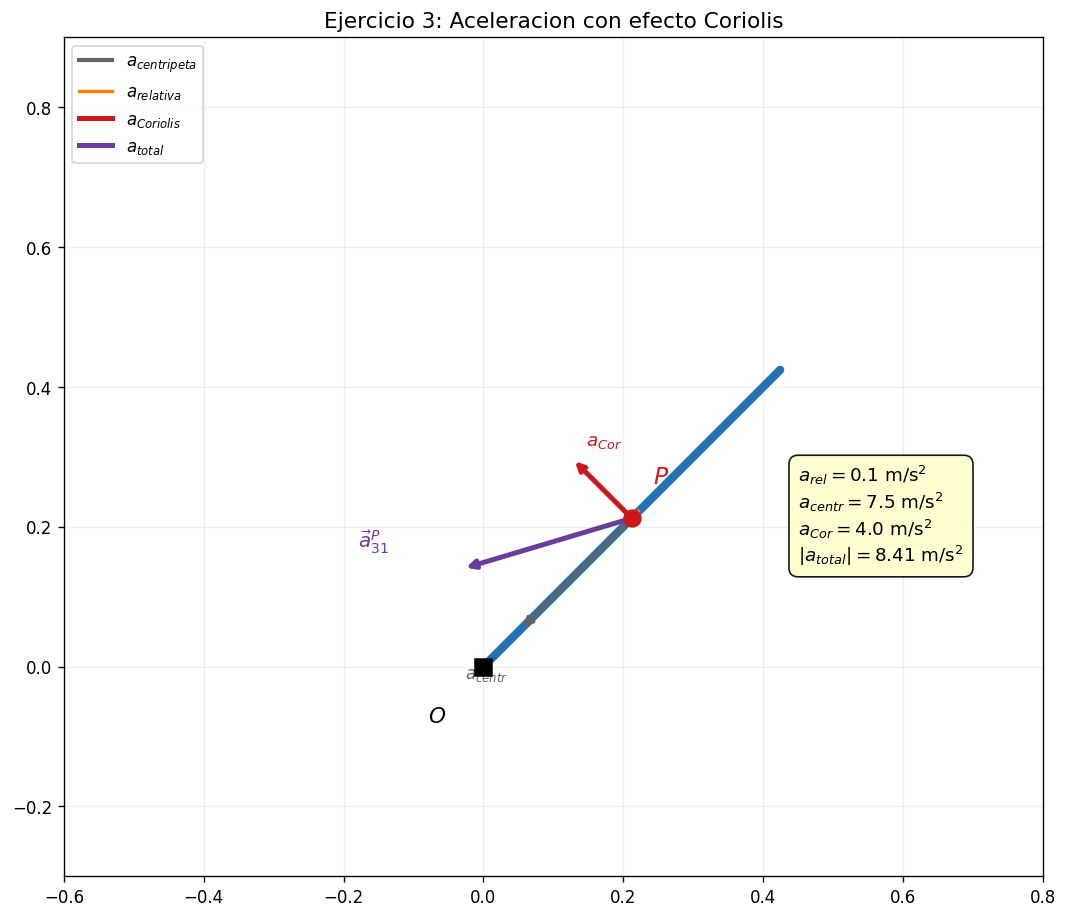

In [9]:
# --- Ejercicio 3: Aceleracion de Coriolis ---
omega_21 = 5.0   # rad/s
alpha_21 = 0.0   # rad/s^2 (constante)
v_32 = 0.4       # m/s (radial, hacia fuera)
a_32 = 0.1       # m/s^2 (radial, hacia fuera)
r_P = 0.3        # m
theta = np.radians(45)

# Vectores unitarios
u_r = np.array([np.cos(theta), np.sin(theta)])
u_theta = np.array([-np.sin(theta), np.cos(theta)])

# Aceleracion relativa (a lo largo de la barra)
a_rel = a_32 * u_r

# Aceleracion de arrastre
a_tang_arr = alpha_21 * r_P * u_theta  # = 0 (alpha=0)
a_cent_arr = -omega_21**2 * r_P * u_r  # centripeta hacia O
a_arrastre = a_tang_arr + a_cent_arr

# Coriolis: 2 * omega_21 * v_32 (perpendicular a v_32)
a_coriolis = 2 * omega_21 * v_32 * u_theta

# Total
a_total = a_rel + a_arrastre + a_coriolis
a_total_mag = np.linalg.norm(a_total)

# --- Visualizacion ---
fig, ax = plt.subplots(1, 1, figsize=(9, 8))
ax.set_xlim(-0.6, 0.8)
ax.set_ylim(-0.3, 0.9)
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)
ax.set_title('Ejercicio 3: Aceleracion con efecto Coriolis', fontsize=13)

O_pos = np.array([0, 0])
P_pos = O_pos + r_P * u_r
B_pos = O_pos + 0.6 * u_r

# Barra
draw_link(ax, O_pos, B_pos, color=COLOR_PRINCIPAL, lw=5)
draw_joint(ax, O_pos, fixed=True, ms=10)
ax.text(-0.08, -0.08, r'$O$', fontsize=13, fontweight='bold')

# Punto P
ax.plot(*P_pos, 'o', color=COLOR_ROJO, ms=10, zorder=6)
ax.text(P_pos[0]+0.03, P_pos[1]+0.05, r'$P$', fontsize=14,
        color=COLOR_ROJO, fontweight='bold')

# Vectores de aceleracion (escala para visualizacion)
scale = 0.03

# Centripeta
ax.annotate('', xy=P_pos + a_cent_arr*scale, xytext=P_pos,
            arrowprops=dict(arrowstyle='->', color=COLOR_FIJO, lw=2.5))
ax.text(P_pos[0]+a_cent_arr[0]*scale-0.08, P_pos[1]+a_cent_arr[1]*scale-0.07,
        r'$a_{centr}$', fontsize=10, color=COLOR_FIJO)

# Relativa
ax.annotate('', xy=P_pos + a_rel*scale*8, xytext=P_pos,
            arrowprops=dict(arrowstyle='->', color=COLOR_NARANJA, lw=2))

# Coriolis
ax.annotate('', xy=P_pos + a_coriolis*scale, xytext=P_pos,
            arrowprops=dict(arrowstyle='->', color=COLOR_ROJO, lw=3))
ax.text(P_pos[0]+a_coriolis[0]*scale+0.02, P_pos[1]+a_coriolis[1]*scale+0.02,
        r'$a_{Cor}$', fontsize=11, color=COLOR_ROJO, fontweight='bold')

# Total
ax.annotate('', xy=P_pos + a_total*scale, xytext=P_pos,
            arrowprops=dict(arrowstyle='->', color=COLOR_MORADO, lw=3))
ax.text(P_pos[0]+a_total[0]*scale-0.15, P_pos[1]+a_total[1]*scale+0.03,
        r'$\vec{a}_{31}^P$', fontsize=12, color=COLOR_MORADO, fontweight='bold')

# Resultados
res = (f'$a_{{rel}} = {a_32}$ m/s$^2$\n'
       f'$a_{{centr}} = {omega_21**2 * r_P:.1f}$ m/s$^2$\n'
       f'$a_{{Cor}} = {2*omega_21*v_32:.1f}$ m/s$^2$\n'
       f'$|a_{{total}}| = {a_total_mag:.2f}$ m/s$^2$')
ax.text(0.45, 0.15, res, fontsize=11,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffffcc', alpha=0.9))

legend_elements = [
    Line2D([0],[0], color=COLOR_FIJO, lw=2.5, label=r'$a_{centripeta}$'),
    Line2D([0],[0], color=COLOR_NARANJA, lw=2, label=r'$a_{relativa}$'),
    Line2D([0],[0], color=COLOR_ROJO, lw=3, label=r'$a_{Coriolis}$'),
    Line2D([0],[0], color=COLOR_MORADO, lw=3, label=r'$a_{total}$'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

---

## 11. Catalogo de ejercicios

### Tipo A: Formulas de Poisson y derivadas en ejes moviles

**A1.** Un sistema de referencia 2 gira respecto al fijo con $\omega_{21} = 2$ rad/s (constante). Un vector $\vec{B} = t^2 \vec{i}_2 + (1-t)\vec{j}_2$ esta definido en componentes del sistema movil. Calcular $\left.\frac{d\vec{B}}{dt}\right|_1$ en $t = 2$ s.

*Pista*: Aplicar $\left.\frac{d\vec{B}}{dt}\right|_1 = \left.\frac{d\vec{B}}{dt}\right|_2 + \vec{\omega}_{21} \wedge \vec{B}$. Resultado: $(-2)\vec{i}_2 + (8+1)\vec{j}_2$.

**A2.** Un vector unitario $\vec{u}$ rota con velocidad angular $\omega = 6$ rad/s. Calcular $|d\vec{u}/dt|$. (Respuesta: $|d\vec{u}/dt| = \omega = 6$ rad/s, perpendicular a $\vec{u}$.)

---

### Tipo B: Aceleracion de Coriolis

**B1.** En una maquina de ranura, un pin (cuerpo 3) se mueve en una ranura de un disco giratorio (cuerpo 2). El disco gira con $\omega_{21} = 10$ rad/s y $\alpha_{21} = -2$ rad/s$^2$. En el instante analizado, el pin esta a $r = 0.15$ m del centro con velocidad relativa $v_{32} = 0.6$ m/s y aceleracion relativa $a_{32} = -0.3$ m/s$^2$ (hacia dentro). Determinar $\vec{a}_{31}^P$.

*Pista*: No olvidar la aceleracion tangencial de arrastre ($\alpha \neq 0$). Coriolis = $2 \times 10 \times 0.6 = 12$ m/s$^2$.

**B2.** Una persona camina radialmente hacia fuera a $v = 1.5$ m/s sobre un tiovivo que gira a $\omega = 2$ rad/s. A que distancia del centro la aceleracion de Coriolis iguala a la centripeta?

*Pista*: $2\omega v = \omega^2 r \Rightarrow r = 2v/\omega$. Resultado: $r = 1.5$ m.

---

### Tipo C: Movimiento relativo completo

**C1.** En un mecanismo biela-manivela, la manivela $OA$ (cuerpo 2) gira con $\omega_{21} = 100$ rpm constante. La biela $AB$ (cuerpo 3) conecta $A$ con la corredera $B$ (cuerpo 4). Longitudes: $OA = 0.05$ m, $AB = 0.15$ m. Cuando $\theta_{OA} = 90°$, calcular:
  - $\vec{v}_B$ y $\omega_{31}$ usando composicion de velocidades
  - $\vec{a}_B$ incluyendo todos los terminos de composicion

**C2.** Dos discos concentricos giran: el disco interior (2) con $\omega_{21} = 3$ rad/s, el disco exterior (3) con $\omega_{31} = 5$ rad/s (ambos respecto al suelo). Un punto $P$ esta en el borde del disco exterior a distancia $R = 0.2$ m del centro. Calcular $\vec{v}_{32}^P$ y $\vec{a}_{32}^P$.

*Pista*: $\omega_{32} = \omega_{31} - \omega_{21} = 2$ rad/s.

---

## 12. Resumen y formulas clave

### Cinematica del solido rigido

| # | Formula | Nombre |
|---|---------|--------|
| 1 | $\overrightarrow{OP} \cdot (\vec{v}_P - \vec{v}_O) = 0$ | Condicion de rigidez (velocidades) |
| 2 | $\vec{v}_{21}^P = \vec{v}_{21}^O + \vec{\omega}_{21} \wedge \overrightarrow{OP}$ | **Teorema de Chasles** |
| 3 | $\dfrac{d\vec{i}_2}{dt} = \vec{\omega}_{21} \wedge \vec{i}_2$ | **Formulas de Poisson** |
| 4 | $\left.\dfrac{d\vec{A}}{dt}\right|_1 = \left.\dfrac{d\vec{A}}{dt}\right|_2 + \vec{\omega}_{21} \wedge \vec{A}$ | **Derivada en ejes moviles** |
| 5 | $\vec{a}_{21}^P = \vec{a}_{21}^O + \vec{\alpha}_{21} \wedge \overrightarrow{OP} + \vec{\omega}_{21} \wedge (\vec{\omega}_{21} \wedge \overrightarrow{OP})$ | **Aceleracion del solido rigido** |
| 6 | $\vec{a}_{21}^P = \vec{a}_{21}^O + \vec{\alpha}_{21} \wedge \overrightarrow{OP} - \omega_{21}^2 \overrightarrow{OP}$ | Caso plano (BAC-CAB) |

### Movimiento relativo

| # | Formula | Nombre |
|---|---------|--------|
| 7 | $\vec{v}_{31}^P = \vec{v}_{32}^P + \vec{v}_{21}^P$ | **Composicion de velocidades** |
| 8 | $\vec{\omega}_{31} = \vec{\omega}_{32} + \vec{\omega}_{21}$ | **Composicion de omega** |
| 9 | $\vec{a}_{31}^P = \vec{a}_{32}^P + \vec{a}_{21}^P + 2\vec{\omega}_{21} \wedge \vec{v}_{32}^P$ | **Composicion de aceleraciones** (con Coriolis) |
| 10 | $\vec{\alpha}_{ij} = \vec{\alpha}_{ik} + \vec{\alpha}_{kj}$ | Composicion de alpha (plano) |

### Reglas mnemotecnicas

- **Velocidad absoluta** = relativa + arrastre
- **Aceleracion absoluta** = relativa + arrastre + **Coriolis**
- Coriolis aparece cuando hay **rotacion del sistema intermedio** Y **velocidad relativa**
- La aceleracion de Coriolis es **perpendicular** a la velocidad relativa
- En el caso plano: centripeta = $-\omega^2 \overrightarrow{OP}$ (simplificacion BAC-CAB)
- Los indices de omega se "cancelan": $\omega_{ij} = \omega_{ik} + \omega_{kj}$
- Antisimetria: $\omega_{ij} = -\omega_{ji}$